# LSTM Over MFCC Sequences

This notebook keeps each audio clip as a sequence of MFCC frames instead of averaging MFCCs into 40 fixed columns. The LSTM sees inputs shaped like `(batch_size, time_steps, n_mfcc)` and predicts one emotion label per clip.

In [2]:
import glob
import os
import subprocess
import sys
import zipfile
from pathlib import Path

import librosa
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset

SEED = 42
N_MFCC = 40
SAMPLE_RATE = 22050
HOP_LENGTH = 512
KAGGLE_DATASET = "uwrfkaggler/ravdess-emotional-speech-audio"

np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "data"
EXTRACT_DIR = DATA_ROOT / "ravdess"

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Using device: {DEVICE}")

Project root: /Users/kevinwang/chicago_booth/MachineLearning2/Speech-Emotion-Recognition-
Data root: /Users/kevinwang/chicago_booth/MachineLearning2/Speech-Emotion-Recognition-/data
Using device: mps


In [3]:
def ensure_ravdess_data(data_root=DATA_ROOT, extract_dir=EXTRACT_DIR):
    """Return the directory containing Actor_* folders, downloading/extracting if needed."""
    data_root.mkdir(parents=True, exist_ok=True)
    extract_dir.mkdir(parents=True, exist_ok=True)

    actor_dirs = sorted(extract_dir.rglob("Actor_*"))
    if actor_dirs:
        return actor_dirs[0].parent

    zip_paths = sorted(data_root.glob("*.zip"))
    if not zip_paths:
        print(f"Downloading {KAGGLE_DATASET} ...")
        subprocess.run(
            ["kaggle", "datasets", "download", "-d", KAGGLE_DATASET, "-p", str(data_root)],
            check=True,
        )
        zip_paths = sorted(data_root.glob("*.zip"))

    if not zip_paths:
        raise FileNotFoundError("No RAVDESS zip found after download attempt.")

    print(f"Extracting {zip_paths[0]} to {extract_dir} ...")
    with zipfile.ZipFile(zip_paths[0], "r") as z:
        z.extractall(extract_dir)

    actor_dirs = sorted(extract_dir.rglob("Actor_*"))
    if not actor_dirs:
        raise RuntimeError(f"Could not find Actor_* folders under {extract_dir}")
    return actor_dirs[0].parent


def parse_ravdess_filename(filepath):
    parts = Path(filepath).stem.split("-")
    if len(parts) != 7:
        return None

    emotion_code = parts[2]
    emotion_label = EMOTION_MAP.get(emotion_code)
    if emotion_label is None:
        return None

    return {
        "emotion_code": emotion_code,
        "emotion_label": emotion_label,
        "actor_id": parts[6],
    }


DATA_DIR = ensure_ravdess_data()
wav_paths = sorted(glob.glob(str(DATA_DIR / "**" / "*.wav"), recursive=True))

rows = []
for path in wav_paths:
    parsed = parse_ravdess_filename(path)
    if parsed is not None:
        rows.append({"file_path": path, **parsed})

metadata_df = pd.DataFrame(rows)
metadata_df["filename"] = metadata_df["file_path"].map(lambda p: Path(p).name)
metadata_df = (
    metadata_df.drop_duplicates(subset="filename", keep="first")
    .drop(columns="filename")
    .reset_index(drop=True)
)

print(f"DATA_DIR: {DATA_DIR}")
print(f"Audio files found before de-dupe: {len(wav_paths)}")
print(f"Unique parsed clips: {metadata_df.shape[0]}")
metadata_df.head()

DATA_DIR: /Users/kevinwang/chicago_booth/MachineLearning2/Speech-Emotion-Recognition-/data/ravdess
Audio files found before de-dupe: 2880
Unique parsed clips: 1440


,file_path,emotion_code,emotion_label,actor_id
0,/Users/kevinwang/chicago_booth/MachineLearning...,01,neutral,01
1,/Users/kevinwang/chicago_booth/MachineLearning...,01,neutral,01
2,/Users/kevinwang/chicago_booth/MachineLearning...,01,neutral,01
3,/Users/kevinwang/chicago_booth/MachineLearning...,01,neutral,01
4,/Users/kevinwang/chicago_booth/MachineLearning...,02,calm,01


## Train/Test Split

The dataframe still contains one row per audio clip. Unlike the averaged-MFCC notebook, we do not create `mfcc_0` ... `mfcc_39` columns. Each dataset item will load the `.wav`, compute an MFCC matrix, transpose it to `(time_steps, n_mfcc)`, and return that sequence with its label.

In [4]:
label_encoder = LabelEncoder()
metadata_df["label_id"] = label_encoder.fit_transform(metadata_df["emotion_label"])

train_meta_df, test_meta_df = train_test_split(
    metadata_df,
    test_size=0.2,
    random_state=SEED,
    stratify=metadata_df["emotion_label"],
)

train_meta_df = train_meta_df.reset_index(drop=True)
test_meta_df = test_meta_df.reset_index(drop=True)

print(f"Train rows: {train_meta_df.shape[0]}")
print(f"Test rows: {test_meta_df.shape[0]}")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Train rows: 1152
Test rows: 288
{'angry': np.int64(0), 'calm': np.int64(1), 'disgust': np.int64(2), 'fearful': np.int64(3), 'happy': np.int64(4), 'neutral': np.int64(5), 'sad': np.int64(6), 'surprised': np.int64(7)}


In [5]:
class MFCCSequenceDataset(Dataset):
    """Loads each audio clip as a variable-length MFCC sequence."""

    def __init__(self, metadata, n_mfcc=N_MFCC, sample_rate=SAMPLE_RATE, hop_length=HOP_LENGTH):
        self.metadata = metadata.reset_index(drop=True)
        self.n_mfcc = n_mfcc
        self.sample_rate = sample_rate
        self.hop_length = hop_length

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        y, _ = librosa.load(row["file_path"], sr=self.sample_rate)
        mfcc = librosa.feature.mfcc(
            y=y,
            sr=self.sample_rate,
            n_mfcc=self.n_mfcc,
            hop_length=self.hop_length,
        )

        # librosa returns (n_mfcc, time_steps); LSTMs expect (time_steps, features).
        sequence = torch.tensor(mfcc.T, dtype=torch.float32)
        label = torch.tensor(row["label_id"], dtype=torch.long)
        return sequence, label


def collate_mfcc_sequences(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([seq.shape[0] for seq in sequences], dtype=torch.long)
    padded_sequences = pad_sequence(sequences, batch_first=True)
    labels = torch.stack(labels)
    return padded_sequences, lengths, labels


train_dataset = MFCCSequenceDataset(train_meta_df)
test_dataset = MFCCSequenceDataset(test_meta_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_mfcc_sequences,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_mfcc_sequences,
)

sample_batch, sample_lengths, sample_labels = next(iter(train_loader))
print(f"Batch sequence shape: {sample_batch.shape}")
print(f"Batch lengths shape: {sample_lengths.shape}")
print(f"Batch labels shape: {sample_labels.shape}")

/Users/kevinwang/chicago_booth/MachineLearning2/Speech-Emotion-Recognition-/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Batch sequence shape: torch.Size([32, 193, 40])
Batch lengths shape: torch.Size([32])
Batch labels shape: torch.Size([32])


## LSTM Classifier

For this audio setup, `input_dim` is the number of MFCC coefficients per time step. There is no embedding layer because MFCCs are already continuous numeric vectors. The LSTM encodes the variable-length sequence into a final hidden state, and the classifier maps that hidden state to the 8 emotion classes.

In [6]:
class LSTMEmotionClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, n_layers=1, dropout=0.2, bidirectional=True):
        super().__init__()
        self.bidirectional = bidirectional
        self.n_directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * self.n_directions, num_classes)

    def forward(self, x, lengths):
        # x shape: (batch_size, padded_time_steps, n_mfcc)
        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden, _) = self.lstm(packed)

        if self.bidirectional:
            # Concatenate the last forward and backward states from the final LSTM layer.
            final_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            final_hidden = hidden[-1]

        return self.classifier(self.dropout(final_hidden))


INPUT_DIM = N_MFCC
HIDDEN_DIM = 256
NUM_CLASSES = len(label_encoder.classes_)
N_LAYERS = 1
DROPOUT = 0.2

model = LSTMEmotionClassifier(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
    bidirectional=True,
).to(DEVICE)

with torch.no_grad():
    logits = model(sample_batch.to(DEVICE), sample_lengths.to(DEVICE))

print(model)
print(f"Sample logits shape: {logits.shape}")

LSTMEmotionClassifier(
  (lstm): LSTM(40, 256, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=512, out_features=8, bias=True)
)
Sample logits shape: torch.Size([32, 8])


In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device=DEVICE):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for sequences, lengths, labels in loader:
        sequences = sequences.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(sequences, lengths)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += labels.size(0)

    return total_loss / total_examples, total_correct / total_examples


@torch.no_grad()
def evaluate(model, loader, criterion, device=DEVICE):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for sequences, lengths, labels in loader:
        sequences = sequences.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        logits = model(sequences, lengths)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += labels.size(0)

    return total_loss / total_examples, total_correct / total_examples


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Start with a few epochs; MFCC extraction happens on the fly, so this may run slower than the averaged-feature notebook.
N_EPOCHS = 30
BEST_MODEL_PATH = DATA_ROOT / "best_lstm_mfcc_sequences.pt"

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "is_best": [],
}
best_val_loss = float("inf")
best_epoch = None
best_model_state = None

for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, test_loader, criterion)
    is_best = val_loss < best_val_loss

    if is_best:
        best_val_loss = val_loss
        best_epoch = epoch
        best_model_state = {
            name: param.detach().cpu().clone()
            for name, param in model.state_dict().items()
        }
        torch.save(
            {
                "epoch": best_epoch,
                "model_state_dict": best_model_state,
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": best_val_loss,
                "val_acc": val_acc,
                "label_classes": label_encoder.classes_.tolist(),
                "model_config": {
                    "input_dim": INPUT_DIM,
                    "hidden_dim": HIDDEN_DIM,
                    "num_classes": NUM_CLASSES,
                    "n_layers": N_LAYERS,
                    "dropout": DROPOUT,
                    "bidirectional": True,
                },
            },
            BEST_MODEL_PATH,
        )

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["is_best"].append(is_best)

    best_marker = " *best*" if is_best else ""
    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f}, train acc {train_acc:.3f} | "
        f"val loss {val_loss:.4f}, val acc {val_acc:.3f}"
        f"{best_marker}"
    )

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    model.to(DEVICE)
    print(f"Loaded best model from epoch {best_epoch} with val loss {best_val_loss:.4f}")
    print(f"Saved checkpoint to {BEST_MODEL_PATH}")

Epoch 01 | train loss 2.0264, train acc 0.188 | val loss 1.9281, val acc 0.267 *best*
Epoch 02 | train loss 1.8631, train acc 0.293 | val loss 1.8241, val acc 0.292 *best*
Epoch 03 | train loss 1.7458, train acc 0.339 | val loss 1.7622, val acc 0.354 *best*
Epoch 04 | train loss 1.6739, train acc 0.378 | val loss 1.7095, val acc 0.375 *best*
Epoch 05 | train loss 1.5949, train acc 0.430 | val loss 1.6574, val acc 0.389 *best*
Epoch 06 | train loss 1.5381, train acc 0.456 | val loss 1.6275, val acc 0.392 *best*
Epoch 07 | train loss 1.4707, train acc 0.472 | val loss 1.5755, val acc 0.385 *best*
Epoch 08 | train loss 1.4013, train acc 0.508 | val loss 1.5673, val acc 0.396 *best*
Epoch 09 | train loss 1.3755, train acc 0.523 | val loss 1.5391, val acc 0.451 *best*
Epoch 10 | train loss 1.3185, train acc 0.524 | val loss 1.5193, val acc 0.424 *best*
Epoch 11 | train loss 1.2442, train acc 0.583 | val loss 1.4805, val acc 0.434 *best*
Epoch 12 | train loss 1.2007, train acc 0.592 | val lo

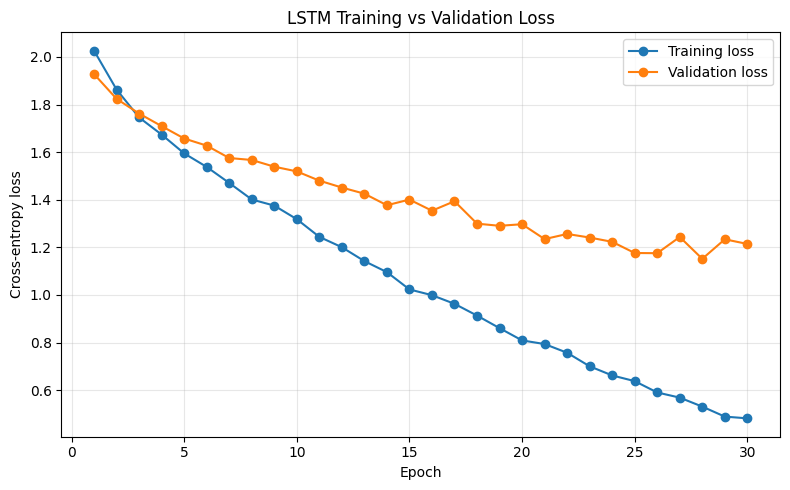

,epoch,train_loss,train_acc,val_loss,val_acc,is_best
0,1,2.026358,0.187500,1.928072,0.267361,True
1,2,1.863064,0.293403,1.824149,0.291667,True
2,3,1.745801,0.338542,1.762225,0.354167,True
3,4,1.673878,0.378472,1.709460,0.375000,True
4,5,1.594936,0.429688,1.657430,0.388889,True
5,6,1.538058,0.455729,1.627529,0.392361,True
6,7,1.470663,0.472222,1.575460,0.385417,True
7,8,1.401306,0.507812,1.567253,0.395833,True
8,9,1.375470,0.523438,1.539058,0.451389,True
9,10,1.318488,0.524306,1.519258,0.423611,True


In [8]:
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Training loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

history_df

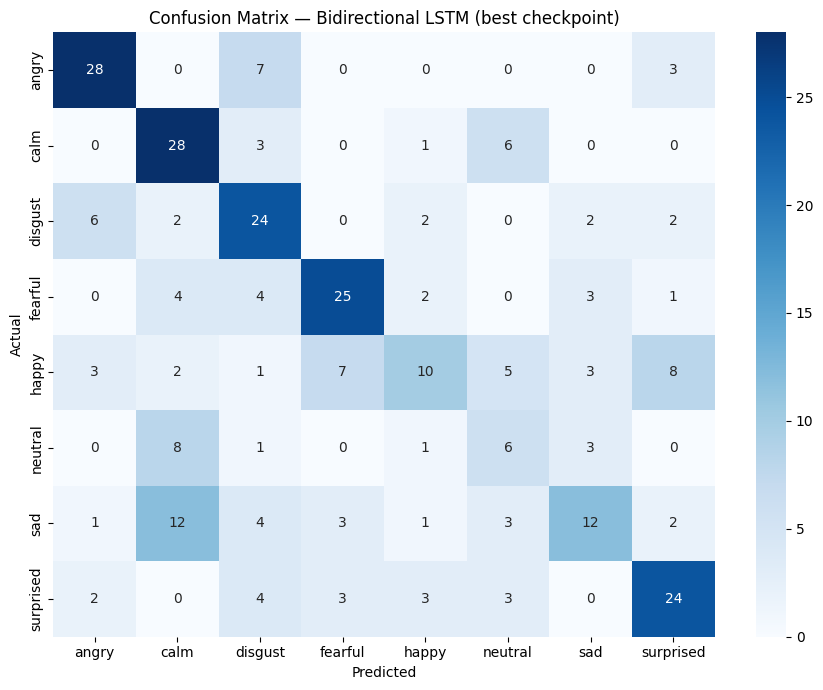

              precision    recall  f1-score   support

       angry       0.70      0.74      0.72        38
        calm       0.50      0.74      0.60        38
     disgust       0.50      0.63      0.56        38
     fearful       0.66      0.64      0.65        39
       happy       0.50      0.26      0.34        39
     neutral       0.26      0.32      0.29        19
         sad       0.52      0.32      0.39        38
   surprised       0.60      0.62      0.61        39

    accuracy                           0.55       288
   macro avg       0.53      0.53      0.52       288
weighted avg       0.55      0.55      0.53       288



In [9]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for sequences, lengths, labels in test_loader:
        sequences = sequences.to(DEVICE)
        lengths = lengths.to(DEVICE)
        logits = model(sequences, lengths)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

emotion_names = label_encoder.classes_
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=emotion_names,
    yticklabels=emotion_names,
)
plt.title("Confusion Matrix — Bidirectional LSTM (best checkpoint)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=emotion_names))